# Preprocessing All Human Cash-Game Texas Hold'em Data

This notebook preprocesses the human cash-game Texas Hold'em portion of the IRC Poker Database and produces the player-level features needed for the project reports.

## Why this notebook exists
- Narrow the project scope to human cash-game Texas Hold'em only
- Build a reproducible preprocessing pipeline over the full selected raw dataset
- Show each major preprocessing step clearly for the report and demo
- Produce a clean player-level feature table for heuristic labeling and K-Means clustering


## Scope and Outputs

### Included channels
- `h1-nobots`
- `holdem`
- `holdem1`
- `holdemii`
- `holdem2`
- `holdem3`
- `holdempot`
- `nolimit`

### Excluded channels
- bot-only channels
- tournament channels
- non-Hold'em games such as Omaha and Stud

### Main outputs
- `data/processed/player_stats_all_human_holdem.csv`
- `data/processed/holdem_human_channel_summary.csv`
- `data/intermediate/holdem_human_parse_summary.csv`


In [1]:
from __future__ import annotations

import os
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/My Drive/CS 4824 Group Project/'
RAW_ROOT = PROJECT_ROOT + 'data/raw'
INTERMEDIATE_DIR = PROJECT_ROOT + 'data/intermediate'
PROCESSED_DIR = PROJECT_ROOT + 'data/processed'
FIGURES_DIR = PROJECT_ROOT + 'figures'

os.makedirs(INTERMEDIATE_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

TARGET_CHANNELS = [
    'holdem',
    'holdem1',
    'holdemii',
]

MIN_HANDS = 30

PARSE_SUMMARY_PATH = INTERMEDIATE_DIR + '/holdem_human_parse_summary.csv'
PLAYER_STATS_PATH = PROCESSED_DIR + '/player_stats_all_human_holdem.csv'
CHANNEL_SUMMARY_PATH = PROCESSED_DIR + '/holdem_human_channel_summary.csv'
VPIP_PFR_FIG_PATH = FIGURES_DIR + '/holdem_human_vpip_pfr_histograms.png'
HEURISTIC_SCATTER_FIG_PATH = FIGURES_DIR + '/holdem_human_heuristic_scatter.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Discover Raw Files

We first identify every `pdb` file in the selected Texas Hold'em channels. Each file corresponds to one player log for a specific month and channel.

In [3]:
def discover_pdb_files(raw_root: str, channels: list[str]) -> pd.DataFrame:
    rows = []

    for channel in channels:
        channel_root = os.path.join(raw_root, channel)
        if not os.path.exists(channel_root):
            print(f'Skipping missing channel: {channel}')
            continue

        for month_name in sorted(os.listdir(channel_root)):
            month_dir = os.path.join(channel_root, month_name)
            if not os.path.isdir(month_dir):
                continue

            pdb_dir = os.path.join(month_dir, 'pdb')
            if not os.path.exists(pdb_dir):
                continue

            for pdb_name in sorted(os.listdir(pdb_dir)):
                pdb_file = os.path.join(pdb_dir, pdb_name)
                if os.path.isfile(pdb_file) and pdb_name.startswith('pdb.'):
                    rows.append({
                        'channel': channel,
                        'month': month_name,
                        'filepath': pdb_file,
                    })

    files_df = pd.DataFrame(rows)
    if not files_df.empty:
        files_df = files_df.sort_values(['channel', 'month', 'filepath']).reset_index(drop=True)
    return files_df


files_df = discover_pdb_files(RAW_ROOT, TARGET_CHANNELS)
print(f'Total pdb files discovered: {len(files_df):,}')
display(files_df.head())

Total pdb files discovered: 83,815


,channel,month,filepath
0,holdem,199504,/content/drive/My Drive/CS 4824 Group Project/...
1,holdem,199504,/content/drive/My Drive/CS 4824 Group Project/...
2,holdem,199504,/content/drive/My Drive/CS 4824 Group Project/...
3,holdem,199504,/content/drive/My Drive/CS 4824 Group Project/...
4,holdem,199504,/content/drive/My Drive/CS 4824 Group Project/...


In [4]:
file_counts_by_channel = files_df.groupby('channel').size().rename('num_files').sort_values(ascending=False)
file_counts_by_month = files_df.groupby('month').size().rename('num_files').sort_index()

display(file_counts_by_channel.to_frame())
display(file_counts_by_month.head(12).to_frame())

,num_files
channel,
holdem,67219
holdem1,15306
holdemii,1290


,num_files
month,
199504,582
199505,462
199506,463
199507,529
199508,567
199509,522
199510,589
199511,723
199512,748


The file discovery step tells us the scale of the preprocessing job and confirms that we are only working with the intended Hold'em channels.

## Preview Raw Records

Before writing the full parser, we inspect a small sample of raw lines to verify the token layout and confirm that the selected channels share the same general record format.

In [5]:
sample_file = files_df.iloc[0]['filepath']
sample_lines = []

with open(sample_file, 'rt', errors='replace') as handle:
    for _ in range(5):
        sample_lines.append(next(handle).rstrip('\n'))

for i, line in enumerate(sample_lines, start=1):
    print(f'Line {i}: {line}')

Line 1: ACC       797555488 12  2 Bf  -     -     -         1000   10    0 
Line 2: ACC       797555580 11  1 Bf  -     -     -          990    5    0 
Line 3: ACC       797555677 10 10 f   -     -     -          985    0    0 
Line 4: ACC       797555788 10  9 f   -     -     -          985    0    0 
Line 5: ACC       797555868  9  8 f   -     -     -          985    0    0 


## Parser and Feature Logic

From each raw line we extract the player name, hand ID, number of players, seat position, and action strings for each betting round.

For the current project scope, the key pre-flop features are:
- **VPIP**: whether the player voluntarily put money into the pot pre-flop
- **PFR**: whether the player raised pre-flop

Forced blind posts are excluded from VPIP so that the statistic reflects voluntary participation.

In [6]:
def parse_pdb_line(line: str) -> dict | None:
    parts = line.split()
    if len(parts) < 8:
        return None

    record = {
        'player': parts[0],
        'hand_id': parts[1],
        'num_players': parts[2],
        'position': parts[3],
        'preflop_actions': parts[4],
        'flop_actions': parts[5],
        'turn_actions': parts[6],
        'river_actions': parts[7],
    }

    if len(parts) > 8:
        record['bankroll'] = parts[8]
    if len(parts) > 9:
        record['winnings'] = parts[9]
    if len(parts) > 10:
        record['shown_cards'] = ' '.join(parts[10:])

    return record


def compute_vpip_pfr(preflop_actions: str) -> tuple[int, int]:
    if preflop_actions == '-':
        return 0, 0

    voluntary_actions = preflop_actions.replace('B', '')
    vpip = int(bool(re.search(r'[bcrA]', voluntary_actions)))
    pfr = int(bool(re.search(r'[rA]', voluntary_actions)))
    return vpip, pfr

In [7]:
parsed_preview = pd.DataFrame([parse_pdb_line(line) for line in sample_lines])
parsed_preview['VPIP_flag'] = parsed_preview['preflop_actions'].apply(lambda x: compute_vpip_pfr(str(x))[0])
parsed_preview['PFR_flag'] = parsed_preview['preflop_actions'].apply(lambda x: compute_vpip_pfr(str(x))[1])
display(parsed_preview)

,player,hand_id,num_players,position,preflop_actions,flop_actions,turn_actions,river_actions,bankroll,winnings,shown_cards,VPIP_flag,PFR_flag
0,ACC,797555488,12,2,Bf,-,-,-,1000,10,0,0,0
1,ACC,797555580,11,1,Bf,-,-,-,990,5,0,0,0
2,ACC,797555677,10,10,f,-,-,-,985,0,0,0,0
3,ACC,797555788,10,9,f,-,-,-,985,0,0,0,0
4,ACC,797555868,9,8,f,-,-,-,985,0,0,0,0


This preview acts as a quick parser sanity check before we process the full dataset.

## Incremental Aggregation Over All Selected Files

Because the full selected Hold'em data is much larger than the sampled demo subset, we stream through the files and aggregate counters by player instead of storing every player-hand row in memory.

In [8]:
player_totals = defaultdict(lambda: {
    'total_hands': 0,
    'vpip_hands': 0,
    'pfr_hands': 0,
    'channels_played': set(),
    'months_played': set(),
})

channel_hand_counter = Counter()
channel_player_counter = defaultdict(set)
file_parse_rows = []
malformed_lines = 0

for idx, row in files_df.iterrows():
    filepath = row['filepath']
    channel = row['channel']
    month = row['month']
    opener = gzip.open if filepath.endswith('.gz') else open

    parsed_lines = 0
    bad_lines = 0

    with opener(filepath, 'rt', errors='replace') as handle:
        for line in handle:
            record = parse_pdb_line(line)
            if record is None:
                malformed_lines += 1
                bad_lines += 1
                continue

            vpip, pfr = compute_vpip_pfr(str(record['preflop_actions']))
            player = record['player']

            player_totals[player]['total_hands'] += 1
            player_totals[player]['vpip_hands'] += vpip
            player_totals[player]['pfr_hands'] += pfr
            player_totals[player]['channels_played'].add(channel)
            player_totals[player]['months_played'].add(month)

            channel_hand_counter[channel] += 1
            channel_player_counter[channel].add(player)
            parsed_lines += 1

    file_parse_rows.append({
        'channel': channel,
        'month': month,
        'filepath': filepath.replace(PROJECT_ROOT, ''),
        'parsed_lines': parsed_lines,
        'bad_lines': bad_lines,
    })

    if (idx + 1) % 1000 == 0 or idx + 1 == len(files_df):
        print(f'Processed {idx + 1:,}/{len(files_df):,} files')

parse_summary_df = pd.DataFrame(file_parse_rows)
parse_summary_df.to_csv(PARSE_SUMMARY_PATH, index=False)

print(f'Total malformed lines skipped: {malformed_lines:,}')
print(f'Parse summary saved to: {PARSE_SUMMARY_PATH}')

Processed 1,000/83,815 files
Processed 2,000/83,815 files
Processed 3,000/83,815 files
Processed 4,000/83,815 files
Processed 5,000/83,815 files
Processed 6,000/83,815 files
Processed 7,000/83,815 files
Processed 8,000/83,815 files
Processed 9,000/83,815 files
Processed 10,000/83,815 files
Processed 11,000/83,815 files
Processed 12,000/83,815 files
Processed 13,000/83,815 files
Processed 14,000/83,815 files
Processed 15,000/83,815 files
Processed 16,000/83,815 files
Processed 17,000/83,815 files
Processed 18,000/83,815 files
Processed 19,000/83,815 files
Processed 20,000/83,815 files
Processed 21,000/83,815 files
Processed 22,000/83,815 files
Processed 23,000/83,815 files
Processed 24,000/83,815 files
Processed 25,000/83,815 files
Processed 26,000/83,815 files
Processed 27,000/83,815 files
Processed 28,000/83,815 files
Processed 29,000/83,815 files
Processed 30,000/83,815 files
Processed 31,000/83,815 files
Processed 32,000/83,815 files
Processed 33,000/83,815 files
Processed 34,000/83

In [9]:
display(parse_summary_df.head())
display(parse_summary_df[['parsed_lines', 'bad_lines']].describe().round(2))

,channel,month,filepath,parsed_lines,bad_lines
0,holdem,199504,data/raw/holdem/199504/pdb/pdb.ACC,61,0
1,holdem,199504,data/raw/holdem/199504/pdb/pdb.ACESUP,1438,0
2,holdem,199504,data/raw/holdem/199504/pdb/pdb.AOLGOOROO,5,0
3,holdem,199504,data/raw/holdem/199504/pdb/pdb.AOL_D00D,40,0
4,holdem,199504,data/raw/holdem/199504/pdb/pdb.AOL_GRUU,4,0


,parsed_lines,bad_lines
count,83815.00,83815.00
mean,233.61,0.00
std,624.29,0.03
min,0.00,0.00
25%,20.00,0.00
50%,72.00,0.00
75%,233.00,0.00
max,41621.00,1.00


At this point we have completed the raw parsing pass and created enough aggregated information to move from raw hand logs to player-level behavioral features. In this full run, that means parsing 83,815 files and building aggregate counters for 24,786 distinct players before any reliability filtering is applied.


## Build the Player-Level Feature Table

We now convert the aggregated counters into a player-level dataset and compute `VPIP` and `PFR` as percentages of total hands played.

In [10]:
player_rows = []

for player, stats in player_totals.items():
    player_rows.append({
        'player': player,
        'total_hands': stats['total_hands'],
        'vpip_hands': stats['vpip_hands'],
        'pfr_hands': stats['pfr_hands'],
        'channels_played_count': len(stats['channels_played']),
        'months_played_count': len(stats['months_played']),
        'channels_played': ','.join(sorted(stats['channels_played'])),
    })

player_stats_full = pd.DataFrame(player_rows)
player_stats_full['VPIP'] = (player_stats_full['vpip_hands'] / player_stats_full['total_hands']) * 100
player_stats_full['PFR'] = (player_stats_full['pfr_hands'] / player_stats_full['total_hands']) * 100
player_stats_full = player_stats_full.sort_values('total_hands', ascending=False).reset_index(drop=True)

print(f'Players before filtering: {len(player_stats_full):,}')
display(player_stats_full.head())

Players before filtering: 24,786


,player,total_hands,vpip_hands,pfr_hands,channels_played_count,months_played_count,channels_played,VPIP,PFR
0,r00lbot,280960,39561,17185,2,23,"holdem,holdem1",14.080652,6.116529
1,kfish,258148,67594,21722,3,48,"holdem,holdem1,holdemii",26.184204,8.414553
2,kwAAkbot,194651,45736,12424,2,19,"holdem,holdem1",23.496412,6.382705
3,loki,101821,31311,12498,3,11,"holdem,holdem1,holdemii",30.751024,12.274482
4,Funky,83715,44765,661,2,29,"holdem,holdem1",53.473093,0.789584


## Data Quality Checks

Before filtering and saving the dataset, we run simple checks that help validate the preprocessing output.

In [11]:
missing_summary = player_stats_full.isna().sum().rename('missing_values')
duplicate_players = int(player_stats_full['player'].duplicated().sum())
vpip_bounds_violations = int(((player_stats_full['VPIP'] < 0) | (player_stats_full['VPIP'] > 100)).sum())
pfr_bounds_violations = int(((player_stats_full['PFR'] < 0) | (player_stats_full['PFR'] > 100)).sum())
pfr_gt_vpip_violations = int((player_stats_full['PFR'] > player_stats_full['VPIP']).sum())

print(f'Duplicate player rows: {duplicate_players}')
print(f'VPIP outside [0, 100]: {vpip_bounds_violations}')
print(f'PFR outside [0, 100]: {pfr_bounds_violations}')
print(f'PFR > VPIP violations: {pfr_gt_vpip_violations}')
display(missing_summary.to_frame().T)

Duplicate player rows: 0
VPIP outside [0, 100]: 0
PFR outside [0, 100]: 0
PFR > VPIP violations: 0


,player,total_hands,vpip_hands,pfr_hands,channels_played_count,months_played_count,channels_played,VPIP,PFR
missing_values,0,0,0,0,0,0,0,0,0


In [12]:
player_stats = player_stats_full[player_stats_full['total_hands'] >= MIN_HANDS].copy()
player_stats = player_stats.reset_index(drop=True)

print(f'Players after filtering to at least {MIN_HANDS} hands: {len(player_stats):,}')
print(f'Players removed by minimum-hands filter: {len(player_stats_full) - len(player_stats):,}')
display(player_stats.head())

Players after filtering to at least 30 hands: 16,439
Players removed by minimum-hands filter: 8,347


,player,total_hands,vpip_hands,pfr_hands,channels_played_count,months_played_count,channels_played,VPIP,PFR
0,r00lbot,280960,39561,17185,2,23,"holdem,holdem1",14.080652,6.116529
1,kfish,258148,67594,21722,3,48,"holdem,holdem1,holdemii",26.184204,8.414553
2,kwAAkbot,194651,45736,12424,2,19,"holdem,holdem1",23.496412,6.382705
3,loki,101821,31311,12498,3,11,"holdem,holdem1,holdemii",30.751024,12.274482
4,Funky,83715,44765,661,2,29,"holdem,holdem1",53.473093,0.789584


The minimum-hands filter improves statistical reliability by removing players for whom VPIP and PFR estimates would be too noisy. Here it removes 8,347 players and leaves 16,439 players with at least 30 hands, which gives the downstream clustering notebook a much more stable feature table.


## Descriptive Summary of the Filtered Dataset

In [13]:
display(player_stats[['total_hands', 'VPIP', 'PFR']].describe().round(2))
display(player_stats[['VPIP', 'PFR', 'total_hands']].corr().round(3))

,total_hands,VPIP,PFR
count,16439.00,16439.00,16439.00
mean,1185.77,51.08,15.01
std,4742.66,19.14,16.64
min,30.00,0.00,0.00
25%,81.00,36.55,5.00
50%,225.00,48.84,9.90
75%,822.00,64.15,18.15
max,280960.00,100.00,100.00


,VPIP,PFR,total_hands
VPIP,1.000,0.485,-0.102
PFR,0.485,1.000,-0.066
total_hands,-0.102,-0.066,1.000


In [14]:
channel_summary = pd.DataFrame({
    'channel': TARGET_CHANNELS,
    'num_parsed_hands': [channel_hand_counter[channel] for channel in TARGET_CHANNELS],
    'num_unique_players': [len(channel_player_counter[channel]) for channel in TARGET_CHANNELS],
}).sort_values('num_parsed_hands', ascending=False)

channel_summary.to_csv(CHANNEL_SUMMARY_PATH, index=False)
display(channel_summary)

,channel,num_parsed_hands,num_unique_players
0,holdem,16370077,23273
1,holdem1,3062038,6449
2,holdemii,147960,837


These summaries help us describe the dataset size and overall behavior patterns in the methodology and final report. The filtered full dataset has mean VPIP about 51.08% and mean PFR about 15.01%, while the number of hands per player remains highly skewed. The channel summary also shows that `holdem` dominates the dataset volume, with `holdem1` contributing a substantial but smaller share and `holdemii` contributing a much smaller share.


## Feature Distribution Visualizations

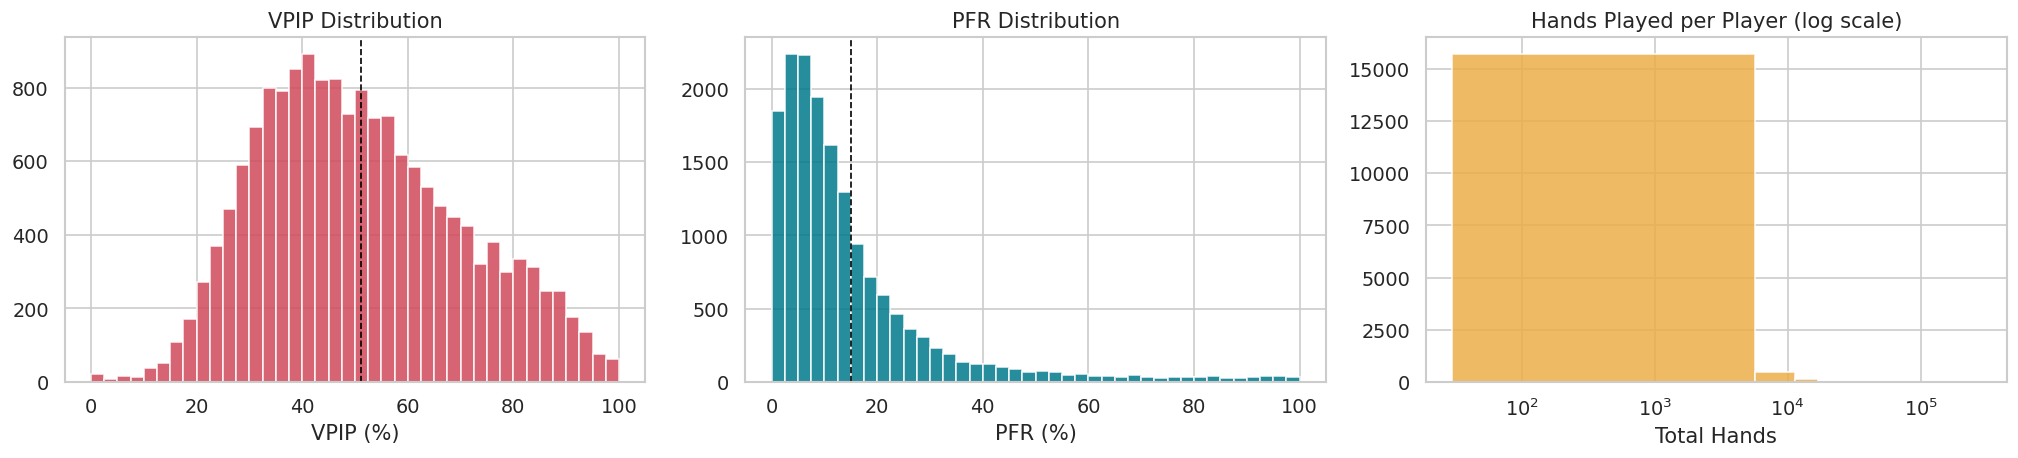

Saved histogram figure to: /content/drive/My Drive/CS 4824 Group Project/figures/holdem_human_vpip_pfr_histograms.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(player_stats['VPIP'], bins=40, color='#d1495b', edgecolor='white', alpha=0.85)
axes[0].axvline(player_stats['VPIP'].mean(), color='black', linestyle='--', linewidth=1)
axes[0].set_title('VPIP Distribution')
axes[0].set_xlabel('VPIP (%)')

axes[1].hist(player_stats['PFR'], bins=40, color='#00798c', edgecolor='white', alpha=0.85)
axes[1].axvline(player_stats['PFR'].mean(), color='black', linestyle='--', linewidth=1)
axes[1].set_title('PFR Distribution')
axes[1].set_xlabel('PFR (%)')

axes[2].hist(player_stats['total_hands'], bins=50, color='#edae49', edgecolor='white', alpha=0.85)
axes[2].set_xscale('log')
axes[2].set_title('Hands Played per Player (log scale)')
axes[2].set_xlabel('Total Hands')

plt.tight_layout()
plt.savefig(VPIP_PFR_FIG_PATH, bbox_inches='tight')
plt.show()

print(f'Saved histogram figure to: {VPIP_PFR_FIG_PATH}')

The histograms help show how loose or tight the player population is overall and whether aggressive pre-flop play is common or relatively rare. In the full dataset, VPIP is broadly spread, but PFR is much more concentrated near lower values, which suggests that many players voluntarily enter pots without frequently raising. That pattern is exactly why VPIP and PFR together are more informative than either feature alone.


## Heuristic Baseline Labels

To stay aligned with the project reports, we assign traditional poker archetypes using VPIP and PFR thresholds.

In [16]:
VPIP_THRESH = 25.0
PFR_THRESH = 15.0

def heuristic_label(row: pd.Series) -> str:
    tight = row['VPIP'] < VPIP_THRESH
    aggressive = row['PFR'] >= PFR_THRESH

    if tight and aggressive:
        return 'TAG'
    if not tight and aggressive:
        return 'LAG'
    if not tight and not aggressive:
        return 'Fish'
    return 'Rock'

player_stats['heuristic_label'] = player_stats.apply(heuristic_label, axis=1)
player_stats['vpip_minus_pfr'] = player_stats['VPIP'] - player_stats['PFR']

display(player_stats['heuristic_label'].value_counts().rename_axis('label').to_frame('count'))

,count
label,
Fish,10140
LAG,5225
Rock,1042
TAG,32


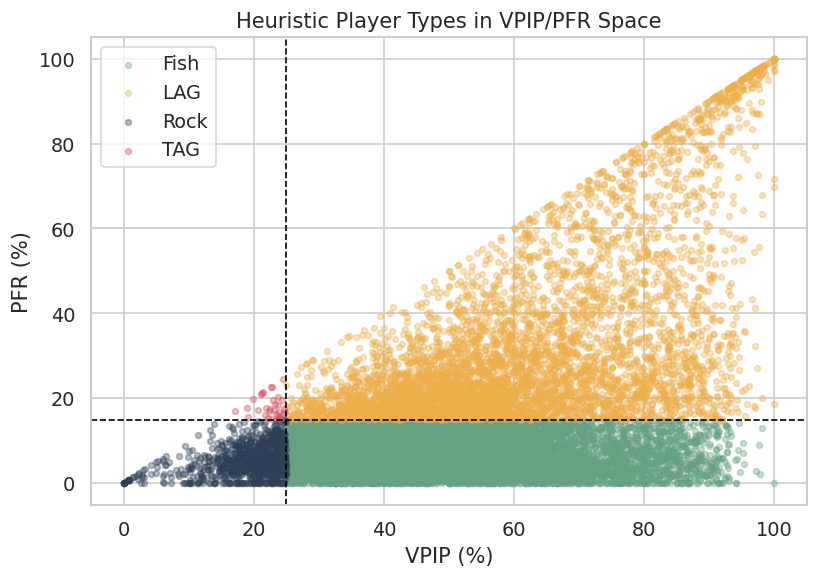

Saved heuristic scatter figure to: /content/drive/My Drive/CS 4824 Group Project/figures/holdem_human_heuristic_scatter.png


In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
palette = {
    'TAG': '#d1495b',
    'LAG': '#edae49',
    'Fish': '#66a182',
    'Rock': '#2e4057',
}

for label, group in player_stats.groupby('heuristic_label'):
    ax.scatter(
        group['VPIP'],
        group['PFR'],
        s=12,
        alpha=0.35,
        label=label,
        color=palette[label],
    )

ax.axvline(VPIP_THRESH, color='black', linestyle='--', linewidth=1)
ax.axhline(PFR_THRESH, color='black', linestyle='--', linewidth=1)
ax.set_title('Heuristic Player Types in VPIP/PFR Space')
ax.set_xlabel('VPIP (%)')
ax.set_ylabel('PFR (%)')
ax.legend()
plt.tight_layout()
plt.savefig(HEURISTIC_SCATTER_FIG_PATH, bbox_inches='tight')
plt.show()

print(f'Saved heuristic scatter figure to: {HEURISTIC_SCATTER_FIG_PATH}')

This plot gives us the rule-based baseline view of the player population before we apply K-Means. The heuristic labels are heavily imbalanced in the filtered full dataset: Fish accounts for 10,140 players, LAG for 5,225, Rock for 1,042, and TAG for only 32. That imbalance is useful to mention later, because it helps explain why a flexible clustering method may describe the feature space better than fixed threshold categories.


## Save Final Outputs

In [18]:
player_stats.to_csv(PLAYER_STATS_PATH, index=False)

print(f'Player-level dataset saved to: {PLAYER_STATS_PATH}')
print(f'Channel summary saved to: {CHANNEL_SUMMARY_PATH}')
print(f'Parse summary saved to: {PARSE_SUMMARY_PATH}')
display(player_stats.head())

Player-level dataset saved to: /content/drive/My Drive/CS 4824 Group Project/data/processed/player_stats_all_human_holdem.csv
Channel summary saved to: /content/drive/My Drive/CS 4824 Group Project/data/processed/holdem_human_channel_summary.csv
Parse summary saved to: /content/drive/My Drive/CS 4824 Group Project/data/intermediate/holdem_human_parse_summary.csv


,player,total_hands,vpip_hands,pfr_hands,channels_played_count,months_played_count,channels_played,VPIP,PFR,heuristic_label,vpip_minus_pfr
0,r00lbot,280960,39561,17185,2,23,"holdem,holdem1",14.080652,6.116529,Rock,7.964123
1,kfish,258148,67594,21722,3,48,"holdem,holdem1,holdemii",26.184204,8.414553,Fish,17.769652
2,kwAAkbot,194651,45736,12424,2,19,"holdem,holdem1",23.496412,6.382705,Rock,17.113706
3,loki,101821,31311,12498,3,11,"holdem,holdem1,holdemii",30.751024,12.274482,Fish,18.476542
4,Funky,83715,44765,661,2,29,"holdem,holdem1",53.473093,0.789584,Fish,52.683510


## Key Takeaways

- We restricted the raw dataset to human cash-game Texas Hold'em channels only.
- We verified the raw record format, parsed 83,815 files incrementally, and aggregated player-level counters for 24,786 players.
- We computed the core project features `VPIP` and `PFR`, then filtered to 16,439 players with at least 30 hands.
- We ran sanity checks, summarized the dataset, visualized the feature distributions, and assigned heuristic player types.
- The filtered dataset is broad and somewhat imbalanced under heuristic labels, which makes it a strong input for the clustering comparison in the next notebook.
